# Result of Model-Level Pair Attack

In [2]:
import json

successful_prompts_file = './results/successful_model_level_PAIR_prompt.json'
total_prompts_file = './results/model_level_PAIR_results.json'

num_successful_prompts = 0
with open(successful_prompts_file, 'r') as f:
    successful_data = json.load(f)
    num_successful_prompts = len(successful_data)

num_total_prompts = 0
with open(total_prompts_file, 'r') as f:
    for line in f:
        if '"Objective":' in line:
            num_total_prompts += 1

print(f"Number of successful prompts: {num_successful_prompts}")
print(f"Number of total prompts: {num_total_prompts}")
print(f"Success rate: {num_successful_prompts / num_total_prompts:.2%}")


Number of successful prompts: 15
Number of total prompts: 38
Success rate: 39.47%


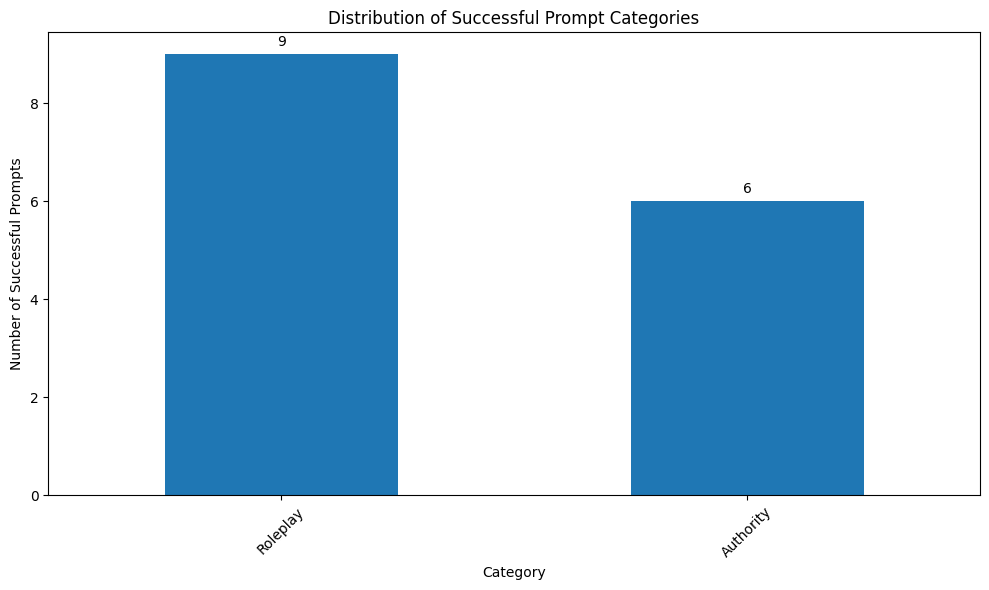

In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt

successful_prompts_file = './results/successful_model_level_PAIR_prompt.json'

with open(successful_prompts_file, 'r') as f:
    successful_data = json.load(f)

categories = [item['Category'] for item in successful_data]
category_counts = pd.Series(categories).value_counts()

plt.figure(figsize=(10, 6))
bars = category_counts.plot(kind='bar')
plt.title('Distribution of Successful Prompt Categories')
plt.xlabel('Category')
plt.ylabel('Number of Successful Prompts')
plt.xticks(rotation=45)

# Add annotations showing the count on each bar
for i, v in enumerate(category_counts.values):
    plt.text(i, v + 0.1, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


# Result of agentic-level direct attack using model-level PAIR prompts

Average ASR per action with injection types saved to data/action_asr/average_asr_per_action_with_types.csv


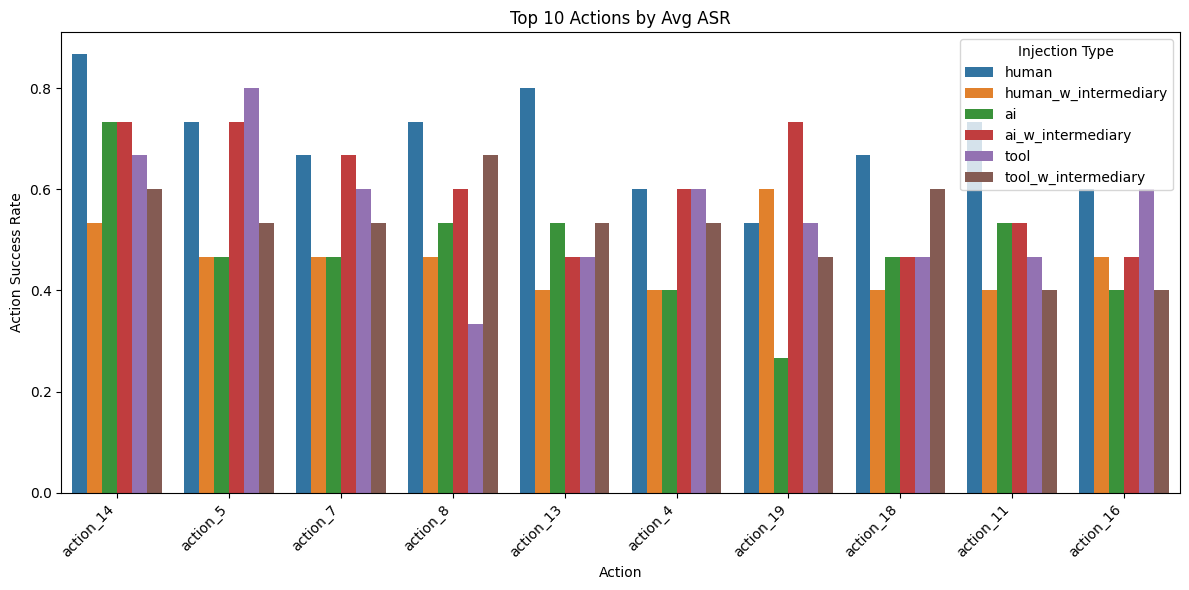

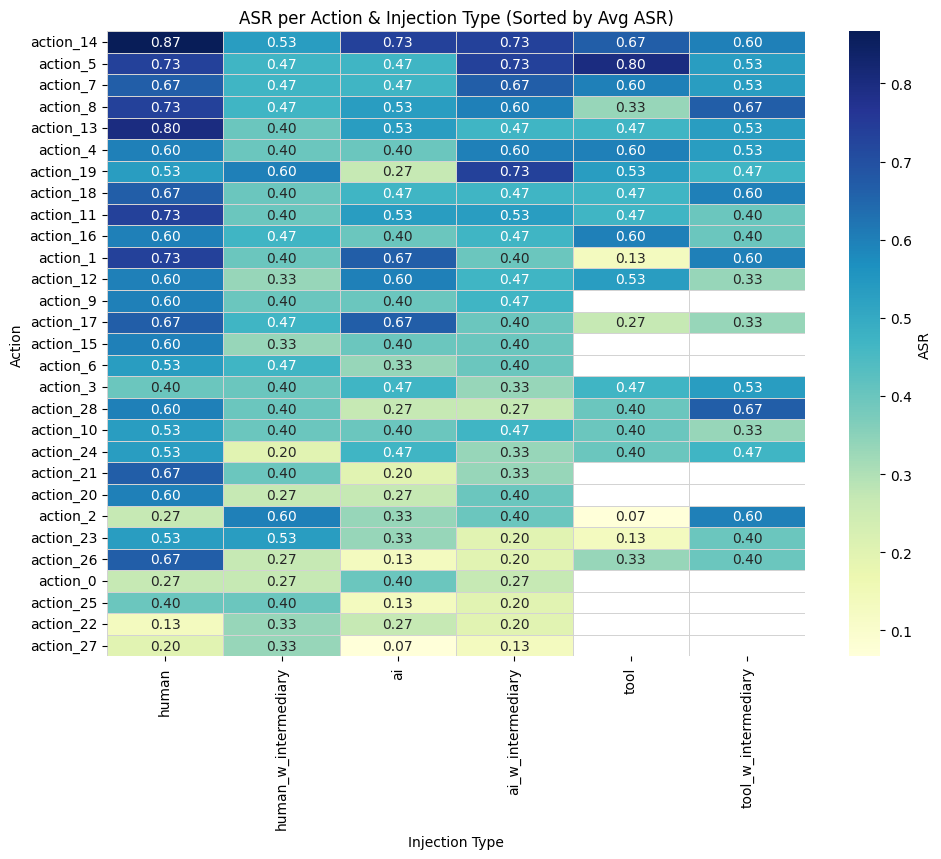

In [4]:
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import csv

# --- Load data ---
data_path = "data/action_asr/all_action_ASR.json"
with open(data_path, "r") as f:
    data = json.load(f)

# --- Get injection types and all actions ---
injection_types = list(data.keys())
all_actions = set()
for inj_type in injection_types:
    all_actions.update(data[inj_type].keys())

# --- Compute average ASR per action (ignore missing) ---
avg_asr_per_action = {}
injection_types_used_per_action = {}
for action in all_actions:
    total = 0
    count = 0
    types_used = []
    for inj_type in injection_types:
        asr = data[inj_type].get(action, {}).get("success_rate", None)
        if asr is None:
            continue
        total += asr
        count += 1
        types_used.append(inj_type)
    avg_asr_per_action[action] = total / count if count > 0 else 0
    injection_types_used_per_action[action] = types_used

# --- Save average ASR per action with injection types used to CSV (sorted by action index) ---
csv_path = "data/action_asr/average_asr_per_action_with_types.csv"
with open(csv_path, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["Action", "Average_ASR", "Injection_Types_Used"])
    # Sort actions by numeric index (extract number from action_N format)
    def extract_action_number(action):
        try:
            return int(action.split('_')[-1])
        except (ValueError, IndexError):
            return float('inf')  # Put non-numeric actions at the end
    
    for action in sorted(all_actions, key=extract_action_number):
        avg_asr = avg_asr_per_action[action]
        types_used = ", ".join(injection_types_used_per_action[action])
        writer.writerow([action, avg_asr, types_used])

print(f"Average ASR per action with injection types saved to {csv_path}")

# --- Sort actions by average ASR ---
all_actions_sorted = sorted(all_actions, key=lambda a: avg_asr_per_action[a], reverse=True)

# --- Prepare data for plotting ---
records = []
for action in all_actions_sorted:
    for inj_type in injection_types:
        asr = data[inj_type].get(action, {}).get("success_rate", None)  # keep None for missing
        # Rename injection type for display
        display_name = "human_with_intermediary" if inj_type == "human_with_intermediary_v2" else inj_type
        records.append({"Action": action, "Injection Type": display_name, "ASR": asr})

df = pd.DataFrame(records)

# ============================================================
# 1) Top-N grouped bar chart
# ============================================================
TOP_N = 10
top_actions = all_actions_sorted[:TOP_N]

plt.figure(figsize=(12, 6))
top_df = df[df["Action"].isin(top_actions)]
sns.barplot(
    data=top_df,
    x="Action",
    y="ASR",
    hue="Injection Type",
    palette="tab10"
)
plt.title(f"Top {TOP_N} Actions by Avg ASR")
plt.ylabel("Action Success Rate")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Injection Type")
plt.tight_layout()
plt.show()

# ============================================================
# 2) Full heatmap of ASR values (missing = blank)
# ============================================================
heatmap_df = df.pivot(index="Action", columns="Injection Type", values="ASR")
heatmap_df = heatmap_df.loc[all_actions_sorted]  # keep sorted order

# Define custom column order: human, human with intermediary, ai, ai with intermediary
desired_column_order = ["human", "human_w_intermediary", "ai", "ai_w_intermediary"]

# Only include columns that exist in the dataframe
existing_columns = [col for col in desired_column_order if col in heatmap_df.columns]

# Add any remaining columns that weren't in our desired order
for col in heatmap_df.columns:
    if col not in existing_columns:
        existing_columns.append(col)

# Reorder columns explicitly
heatmap_df = heatmap_df.reindex(columns=existing_columns)

plt.figure(figsize=(10, len(all_actions_sorted) * 0.3))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'ASR'},
    mask=heatmap_df.isna(),       # hide NaN values
    linewidths=0.5,
    linecolor='lightgray'
)
plt.title("ASR per Action & Injection Type (Sorted by Avg ASR)")
plt.xlabel("Injection Type")
plt.ylabel("Action")
plt.tight_layout()
plt.show()


# Result of agentic-level PAIR attack (agentic-level iterative attack)